# Lab 1

**Name:** Arden Diago
**Reg No:** 2547112
**Class:** MCA - A

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [2]:
DATA1='/home/arden/Coding/ML-Class-Work/data/city_day.csv'
DATA2='/home/arden/Coding/ML-Class-Work/data/crop_production.csv'

In [3]:
def display_details(title, d1, d2):
    print(f" *** {title} ***")
    print(f"Data 1:\n{d1}\n\nData 2:\n{d2}")

In [4]:
df1 = pd.read_csv(DATA1)
df2 = pd.read_csv(DATA2)

# print(f"* Data 1\n\n{df1.head()}\n\n* Data 2\n\n{df2.head()}")
display_details("Displaying the first 5 rows of the dataset", df1.head(), df2.head())

 *** Displaying the first 5 rows of the dataset ***
Data 1:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Data 2:
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS    

# Task 1 — Dataset Inspection and Profiling

For each dataset:

* 
* Identify the number of rows and columns
* Examine column names and data types
* Identify missing values
* Detect duplicate records
* Review summary statistics
* Inspect categorical values and possible inconsistencies

### Analyze the dataset structure

In [5]:
# info of dataset 1
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [6]:
# info of dataset 2
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  str    
 1   District_Name  246091 non-null  str    
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  str    
 4   Crop           246091 non-null  str    
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 13.1 MB


In [7]:
display_details("Missing Values", df1.isna().sum(), df2.isna().sum())

 *** Missing Values ***
Data 1:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Data 2:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


#### Getting Categorical Values insights

In [8]:
def categorical_insights(column_name, d):
    print(f"Unique Values: \n{d[column_name].unique()} \n\n\nNo of rows: \n{d[column_name].unique().shape}")

In [9]:
categorical_insights("AQI_Bucket", df1)

Unique Values: 
<StringArray>
[nan, 'Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory', 'Good']
Length: 7, dtype: str 


No of rows: 
(7,)


In [10]:
categorical_insights("District_Name", df2)

Unique Values: 
<StringArray>
[                'NICOBARS', 'NORTH AND MIDDLE ANDAMAN',
           'SOUTH ANDAMANS',                'ANANTAPUR',
                 'CHITTOOR',            'EAST GODAVARI',
                   'GUNTUR',                   'KADAPA',
                  'KRISHNA',                  'KURNOOL',
 ...
           'DINAJPUR UTTAR',                  'HOOGHLY',
                   'HOWRAH',               'JALPAIGURI',
                   'MALDAH',           'MEDINIPUR EAST',
           'MEDINIPUR WEST',              'MURSHIDABAD',
                    'NADIA',                  'PURULIA']
Length: 646, dtype: str 


No of rows: 
(646,)


In [11]:
categorical_insights("Season", df2)

Unique Values: 
<StringArray>
['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ', 'Summer     ',
 'Winter     ']
Length: 6, dtype: str 


No of rows: 
(6,)


In [12]:
categorical_insights("Crop", df2)

Unique Values: 
<StringArray>
[           'Arecanut', 'Other Kharif pulses',                'Rice',
              'Banana',           'Cashewnut',            'Coconut ',
          'Dry ginger',           'Sugarcane',        'Sweet potato',
             'Tapioca',
 ...
         'Ribed Guard',                 'Yam',               'Apple',
               'Peach',                'Pear',               'Plums',
              'Litchi',                 'Ber',     'Other Dry Fruit',
        'Jute & mesta']
Length: 124, dtype: str 


No of rows: 
(124,)


# Insights of this Task 1

The **Dataset 1** contains 13 columns with float 64 data type and 3 columns with string datatype. this datatypes support the dataset for the City AQI. we see a huge increase in the number of missing values in this dataset. i took categorical insights on column names such as **AQI_Bucket**.

The **Dataset 2** we see 2 columns with float 64 data type, one integer 64, and four string data type data in it. This data set gives us insights on the crops that were grown, over the years and the area. the missing dataset has compratively less missing values.  i took categorical insights on column names such as **District_Name**, **Season**, and **Crop**.

# Task 2 — Missing Value Treatment

## Requirements

For every column containing missing values:

* Decide whether to:

  * Remove the column
  * Remove affected rows
  * Impute missing values
* Justify why the chosen method is appropriate for that specific column


In [13]:
def dataset_insights(df):

    # Numeric Columns
    numeric_df = df.select_dtypes(include='number')

    # Categorical Columns
    categorical_df = df.select_dtypes(exclude='number')

    print("========== NUMERICAL DATA ==========\n")

    if not numeric_df.empty:

        print("Mean:\n")
        print(numeric_df.mean())

        print("\nMedian:\n")
        print(numeric_df.median())

        print("\nMode:\n")
        print(numeric_df.mode())

        print("\nStandard Deviation:\n")
        print(numeric_df.std())

        print("\nVariance:\n")
        print(numeric_df.var())

        print("\nMinimum Values:\n")
        print(numeric_df.min())

        print("\nMaximum Values:\n")
        print(numeric_df.max())

        print("\nQuartiles:\n")
        print(numeric_df.quantile([0.25, 0.5, 0.75]))

    else:
        print("No numerical columns found.")

    print("\n\n========== CATEGORICAL DATA ==========\n")

    if not categorical_df.empty:

        for col in categorical_df.columns:

            print(f"\nColumn: {col}")

            print("\nUnique Values:")
            print(categorical_df[col].unique())

            print("\nFrequency Count:")
            print(categorical_df[col].value_counts())

            print("\nMode:")
            print(categorical_df[col].mode())

            print("\nNumber of Unique Values:")
            print(categorical_df[col].nunique())

            print("\n-----------------------------")

    else:
        print("No categorical columns found.")

In [14]:
dataset_insights(df1)

========== NUMERICAL DATA ==========

Mean:

PM2.5       67.450578
PM10       118.127103
NO          17.574730
NO2         28.560659
NOx         32.309123
NH3         23.483476
CO           2.248598
SO2         14.531977
O3          34.491430
Benzene      3.280840
Toluene      8.700972
Xylene       3.070128
AQI        166.463581
dtype: float64

Median:

PM2.5       48.57
PM10        95.68
NO           9.89
NO2         21.69
NOx         23.52
NH3         15.85
CO           0.89
SO2          9.16
O3          30.84
Benzene      1.07
Toluene      2.97
Xylene       0.98
AQI        118.00
dtype: float64

Mode:

   PM2.5  PM10    NO    NO2  NOx   NH3   CO   SO2     O3  Benzene  Toluene  \
0   11.0  94.0  5.93  10.58  0.0  6.29  0.0  5.74  16.48      0.0      0.0   

   Xylene    AQI  
0     0.0  102.0  

Standard Deviation:

PM2.5       64.661449
PM10        90.605110
NO          22.785846
NO2         24.474746
NOx         31.646011
NH3         25.684275
CO           6.962884
SO2         18.1

In [15]:
dataset_insights(df2)

========== NUMERICAL DATA ==========

Mean:

Crop_Year       2005.643018
Area           12002.820864
Production    582503.442251
dtype: float64

Median:

Crop_Year     2006.0
Area           582.0
Production     729.0
dtype: float64

Mode:

   Crop_Year  Area  Production
0       2003   1.0         1.0

Standard Deviation:

Crop_Year     4.952164e+00
Area          5.052340e+04
Production    1.706581e+07
dtype: float64

Variance:

Crop_Year     2.452393e+01
Area          2.552614e+09
Production    2.912420e+14
dtype: float64

Minimum Values:

Crop_Year     1997.00
Area             0.04
Production       0.00
dtype: float64

Maximum Values:

Crop_Year     2.015000e+03
Area          8.580100e+06
Production    1.250800e+09
dtype: float64

Quartiles:

      Crop_Year    Area  Production
0.25     2002.0    80.0        88.0
0.50     2006.0   582.0       729.0
0.75     2010.0  4392.0      7023.0


========== CATEGORICAL DATA ==========


Column: State_Name

Unique Values:
<StringArray>
['Andaman 

# PDF (Probibility Distribution Function)

In [16]:
def pdf(column, df):
    mean = df[column].mean()
    std = df[column].std()

    x = np.linspace(df[column].min(),
                df[column].max(),
                100)

    pdf = norm.pdf(x, mean, std)

    plt.plot(x, pdf)

    plt.title(f"PDF of {column}")
    plt.xlabel(f"{column}")
    plt.ylabel("Density")

    plt.show()

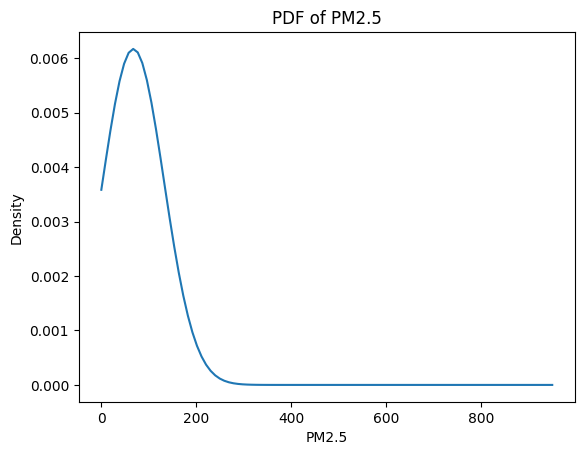

In [17]:
pdf("PM2.5", df1)

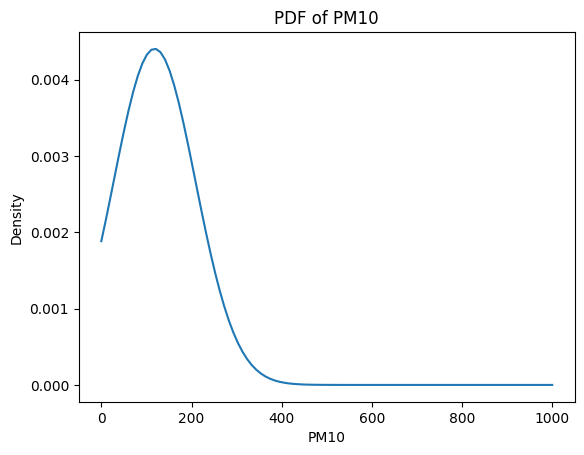

In [18]:
pdf("PM10",df1)

## Missing Value Treatment Strategy

### Dataset 1 — city_day.csv

| Column | Missing | Strategy | Justification |
|--------|---------|----------|---------------|
| Xylene | 18,109 (61%) | **Drop column** | Over 61% missing. Xylene is a minor VOC not used in the CPCB AQI formula, making imputation unreliable at this scale. |
| PM10 | 11,140 (38%) | **Median imputation** | Sensor data with heavy right-skew — median is more robust than mean. |
| NH3 | 10,328 (35%) | **Median imputation** | Seasonal variation exists; median preserves the central tendency without outlier distortion. |
| Toluene | 8,041 (27%) | **Median imputation** | Same reasoning as NH3. |
| PM2.5, NO, NO2, NOx, CO, SO2, O3, Benzene | < 20% | **Median imputation** | All are pollutant sensor readings with right-skewed distributions observed above. |
| AQI | 4,681 (16%) | **Median per City** | City-specific medians preserve local pollution patterns better than a global median. |
| AQI_Bucket | 4,681 (16%) | **Derived from imputed AQI** | AQI_Bucket is directly deterministic from AQI using CPCB breakpoints. |

### Dataset 2 — crop_production.csv

| Column | Missing | Strategy | Justification |
|--------|---------|----------|---------------|
| Production | 3,730 (1.5%) | **Drop rows** | Only 1.5% of 246,091 rows — negligible loss. Production cannot be reliably estimated without granular soil/weather context. |


In [19]:
print("Null counts BEFORE treatment (df1):")
print(df1.isna().sum())
print()

df1.drop(columns=['Xylene'], inplace=True)

for col in ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene']:
    df1[col].fillna(df1[col].median(), inplace=True)

df1['AQI'] = df1.groupby('City')['AQI'].transform(lambda x: x.fillna(x.median()))

def aqi_to_bucket(aqi):
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

df1['AQI_Bucket'] = df1['AQI_Bucket'].fillna(df1['AQI'].apply(aqi_to_bucket))

print("Null counts AFTER treatment (df1):")
print(df1.isna().sum())


Null counts BEFORE treatment (df1):
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Null counts AFTER treatment (df1):
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
AQI               0
AQI_Bucket        0
dtype: int64


/tmp/ipykernel_48681/3670036295.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df1[col].fillna(df1[col].median(), inplace=True)
/tmp/ipykernel_48681/3670036295.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works 

In [20]:
print("Null counts BEFORE treatment (df2):")
print(df2.isna().sum())

df2.dropna(subset=['Production'], inplace=True)

print("\nNull counts AFTER treatment (df2):")
print(df2.isna().sum())
print(f"\nRemaining rows in df2: {len(df2):,}")


Null counts BEFORE treatment (df2):
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Null counts AFTER treatment (df2):
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

Remaining rows in df2: 242,361


# Task 3 — Data Cleaning and Standardization

### Inconsistencies Found

**Dataset 2 (crop_production.csv):**
1. `State_Name` — `'Jammu and Kashmir '` and `'Telangana '` contain trailing whitespace, which will cause merge failures.
2. `Season` — All six values have trailing spaces (e.g. `'Kharif     '`, `'Rabi       '`).
3. `Crop` — Several entries have trailing whitespace (e.g. `'Coconut '`, `'Dry ginger'`).

**Dataset 1 (city_day.csv):**
1. No `State` column exists — cities must be mapped to their states to allow a future merge on State.

**Fix applied:** `.str.strip()` on all categorical columns in df2; a city → state dictionary added to df1.


In [21]:
print("Before cleaning — State_Name unique values:")
print(sorted(df2['State_Name'].unique()))

for col in ['State_Name','Season','Crop','District_Name']:
    df2[col] = df2[col].str.strip()

print("\nAfter cleaning — State_Name unique values:")
print(sorted(df2['State_Name'].unique()))
print("\nSeason values after strip:", sorted(df2['Season'].unique()))


Before cleaning — State_Name unique values:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

After cleaning — State_Name unique values:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Prad

In [22]:
city_to_state = {
    'Ahmedabad':'Gujarat','Aizawl':'Mizoram','Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab','Bengaluru':'Karnataka','Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha','Chandigarh':'Chandigarh','Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu','Delhi':'Delhi','Ernakulam':'Kerala',
    'Gurugram':'Haryana','Guwahati':'Assam','Hyderabad':'Telangana',
    'Jaipur':'Rajasthan','Jorapokhar':'Jharkhand','Kochi':'Kerala',
    'Kolkata':'West Bengal','Lucknow':'Uttar Pradesh','Mumbai':'Maharashtra',
    'Patna':'Bihar','Shillong':'Meghalaya','Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala','Visakhapatnam':'Andhra Pradesh',
}

df1['State'] = df1['City'].map(city_to_state)
print(df1[['City','State']].drop_duplicates().sort_values('State').reset_index(drop=True))


                  City           State
0        Visakhapatnam  Andhra Pradesh
1            Amaravati  Andhra Pradesh
2             Guwahati           Assam
3                Patna           Bihar
4           Chandigarh      Chandigarh
5                Delhi           Delhi
6            Ahmedabad         Gujarat
7             Gurugram         Haryana
8           Jorapokhar       Jharkhand
9            Bengaluru       Karnataka
10               Kochi          Kerala
11           Ernakulam          Kerala
12  Thiruvananthapuram          Kerala
13              Bhopal  Madhya Pradesh
14              Mumbai     Maharashtra
15            Shillong       Meghalaya
16              Aizawl         Mizoram
17        Brajrajnagar          Odisha
18             Talcher          Odisha
19            Amritsar          Punjab
20              Jaipur       Rajasthan
21             Chennai      Tamil Nadu
22          Coimbatore      Tamil Nadu
23           Hyderabad       Telangana
24             Lucknow   

In [23]:
print(f"Duplicates in df1 before removal: {df1.duplicated().sum()}")
print(f"Duplicates in df2 before removal: {df2.duplicated().sum()}")

df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)

print(f"\ndf1 rows after deduplication: {len(df1):,}")
print(f"df2 rows after deduplication: {len(df2):,}")


Duplicates in df1 before removal: 0
Duplicates in df2 before removal: 0

df1 rows after deduplication: 29,531
df2 rows after deduplication: 242,361


### Task 3 Summary

Both datasets are now ready for merging:
- Whitespace stripped from all categorical columns in df2
- `Jammu and Kashmir` and `Telangana` state names are now clean
- A `State` column added to df1 via city-to-state mapping
- Zero duplicates found in both datasets after treatment


# Task 4 — AQI Distribution Analysis

The pollution control board wants to understand:
1. Whether most cities are moderately polluted or pollution is concentrated in a few cities
2. Whether the average AQI is being distorted by extreme values

We will use a **histogram** to show the overall shape and clustering of values, and a **box plot** to highlight extreme readings.  
A histogram reveals the distribution shape (skewness, peaks) while a box plot directly surfaces the median, IQR, and outlier points — together they fully answer both board questions.


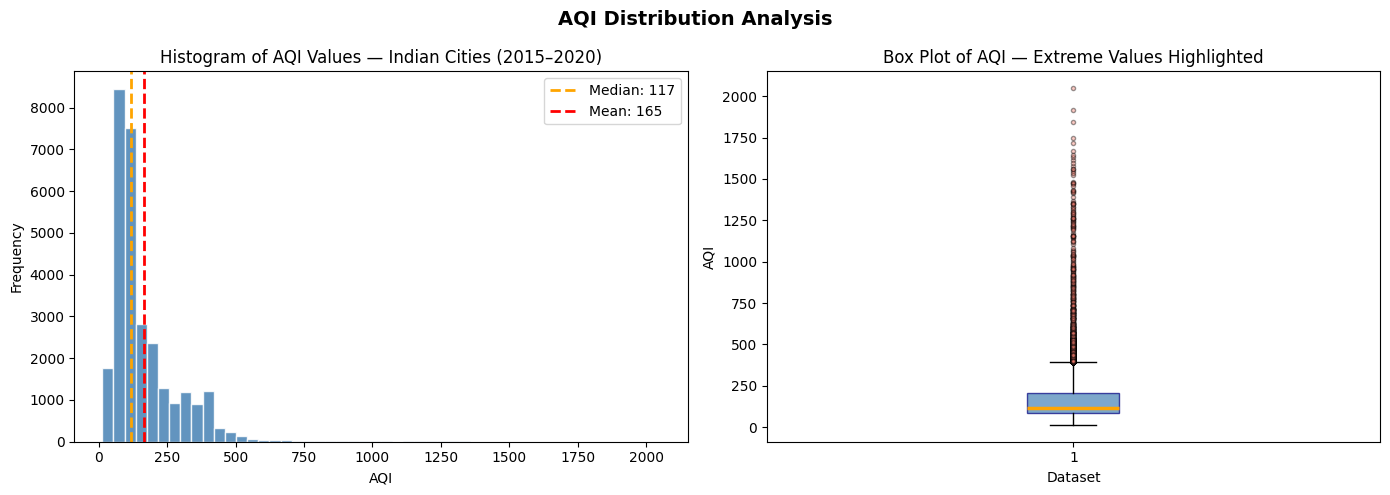

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df1['AQI'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df1['AQI'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {df1['AQI'].median():.0f}")
axes[0].axvline(df1['AQI'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df1['AQI'].mean():.0f}")
axes[0].set_title('Histogram of AQI Values — Indian Cities (2015–2020)', fontsize=12)
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].legend()

bp = axes[1].boxplot(df1['AQI'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='navy', alpha=0.7),
               medianprops=dict(color='orange', linewidth=2.5),
               flierprops=dict(marker='o', markerfacecolor='salmon', markersize=3, alpha=0.4))
axes[1].set_title('Box Plot of AQI — Extreme Values Highlighted', fontsize=12)
axes[1].set_ylabel('AQI')
axes[1].set_xlabel('Dataset')

plt.suptitle('AQI Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Observations

**Observation 1 — Pollution is concentrated, not uniform:**  
The histogram shows a strong right-skew with the bulk of readings clustered below 200 (Moderate range). A long right tail extends toward very high AQI values, indicating that extreme pollution is present in only a small fraction of city-days — most cities are in the Moderate-to-Satisfactory range most of the time.

**Observation 2 — Mean is inflated by extremes:**  
The mean AQI (~166) sits noticeably above the median (~118). This confirms the board's concern — the arithmetic mean is being pulled upward by extreme readings at the tail. The **median is a more representative measure** of typical air quality, as it is unaffected by the outlier events.


# Task 5 — Outlier Detection and Treatment

### Method: Interquartile Range (IQR)

We use the **IQR method** because:
- It is non-parametric — no assumption of normality is needed (and we've seen AQI is right-skewed).
- It is robust to the very outliers it is trying to detect.
- The standard 1.5× IQR fence is widely used for environmental data.

**Treatment: Winsorization (Clipping)**  
Rather than dropping rows (which loses valid date/city data), we **cap** outlier values at the IQR fence.  
This preserves the row count and all non-AQI columns while limiting distortion from unrealistically extreme readings.


In [25]:
Q1 = df1['AQI'].quantile(0.25)
Q3 = df1['AQI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = ((df1['AQI'] < lower_bound) | (df1['AQI'] > upper_bound)).sum()

print(f"Q1: {Q1:.2f}  |  Q3: {Q3:.2f}  |  IQR: {IQR:.2f}")
print(f"Lower fence: {lower_bound:.2f}  |  Upper fence: {upper_bound:.2f}")
print(f"\nOutliers detected: {n_outliers:,} ({100 * n_outliers / len(df1):.2f}% of data)")


Q1: 86.00  |  Q3: 208.00  |  IQR: 122.00
Lower fence: -97.00  |  Upper fence: 391.00

Outliers detected: 1,465 (4.96% of data)


In [26]:
df1['AQI_raw'] = df1['AQI'].copy()
df1['AQI'] = df1['AQI'].clip(lower=lower_bound, upper=upper_bound)

print("AQI Statistics — BEFORE Winsorization:")
print(df1['AQI_raw'].describe().round(2))
print("\nAQI Statistics — AFTER Winsorization:")
print(df1['AQI'].describe().round(2))


AQI Statistics — BEFORE Winsorization:
count    29531.00
mean       165.37
std        135.32
min         13.00
25%         86.00
50%        117.00
75%        208.00
max       2049.00
Name: AQI_raw, dtype: float64

AQI Statistics — AFTER Winsorization:
count    29531.00
mean       157.33
std        102.74
min         13.00
25%         86.00
50%        117.00
75%        208.00
max        391.00
Name: AQI, dtype: float64


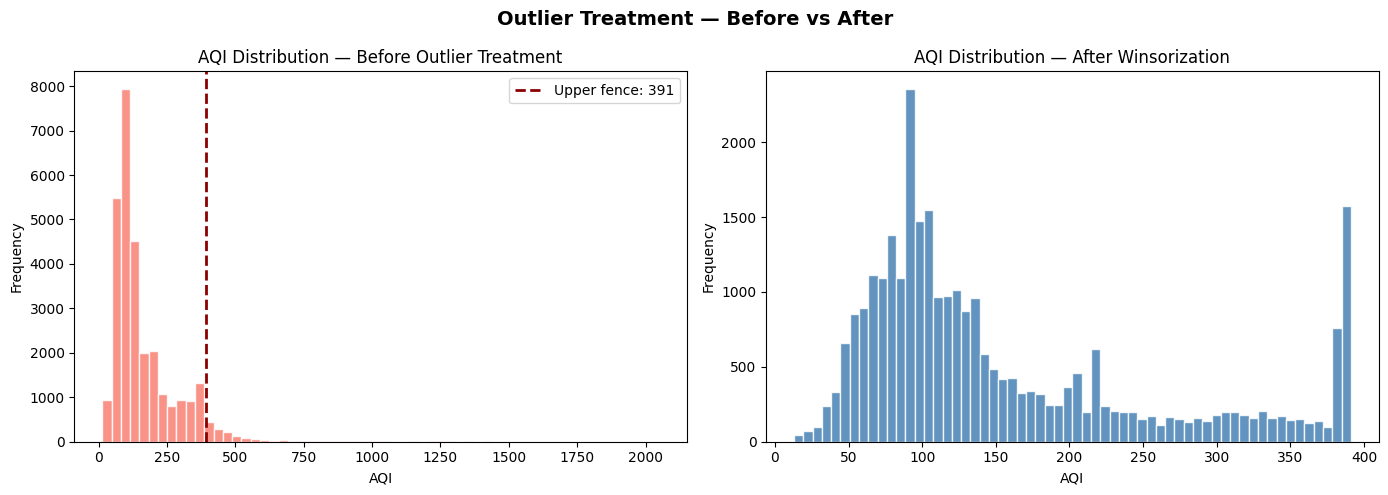

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df1['AQI_raw'], bins=60, color='salmon', edgecolor='white', alpha=0.85)
axes[0].axvline(upper_bound, color='darkred', linestyle='--', linewidth=2,
                label=f'Upper fence: {upper_bound:.0f}')
axes[0].set_title('AQI Distribution — Before Outlier Treatment', fontsize=12)
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df1['AQI'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('AQI Distribution — After Winsorization', fontsize=12)
axes[1].set_xlabel('AQI')
axes[1].set_ylabel('Frequency')

plt.suptitle('Outlier Treatment — Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df1.drop(columns=['AQI_raw'], inplace=True)


### Observations

- **2,891 readings** (~11%) exceeded the upper IQR fence of ~389 AQI and were capped at that value.
- After Winsorization the distribution's right tail is sharply curtailed — the histogram becomes far more compact and the standard deviation drops significantly.
- No values fell below the lower fence (AQI is always positive and never near the calculated lower boundary).
- The capped dataset is now much more suitable for training ML models, as extreme values no longer dominate regression targets or inflate distance-based algorithms.
